In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("/content/Students Performance .csv")
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 145
Columns: 15


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(145, 15)

Column Names:
['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation', 'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work', 'Grade']

First 5 Rows:


,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Student_ID            object
Student_Age           object
Sex                   object
High_School_Type      object
Scholarship           object
Additional_Work       object
Sports_activity       object
Transportation        object
Weekly_Study_Hours     int64
Attendance            object
Reading               object
Notes                 object
Listening_in_Class    object
Project_work          object
Grade                 object
dtype: object

Missing Values:
Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


In [5]:
print("Duplicate rows before removal:", df.duplicated().sum())

Duplicate rows before removal: 0


In [6]:
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Duplicate rows after removal: 0
Dataset shape after cleaning: (145, 15)


In [7]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Weekly_Study_Hours
count,145.000000
mean,2.331034
std,4.249273
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,12.000000


In [8]:
print("Categorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nUnique Values in Categorical Columns:")

for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical Columns:
['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work', 'Grade']

Unique Values in Categorical Columns:

Student_ID:
['STUDENT1' 'STUDENT2' 'STUDENT3' 'STUDENT4' 'STUDENT5' 'STUDENT6'
 'STUDENT7' 'STUDENT8' 'STUDENT9' 'STUDENT10' 'STUDENT11' 'STUDENT12'
 'STUDENT13' 'STUDENT14' 'STUDENT15' 'STUDENT16' 'STUDENT17' 'STUDENT18'
 'STUDENT19' 'STUDENT20' 'STUDENT21' 'STUDENT22' 'STUDENT23' 'STUDENT24'
 'STUDENT25' 'STUDENT26' 'STUDENT27' 'STUDENT28' 'STUDENT29' 'STUDENT30'
 'STUDENT31' 'STUDENT32' 'STUDENT33' 'STUDENT34' 'STUDENT35' 'STUDENT36'
 'STUDENT37' 'STUDENT38' 'STUDENT39' 'STUDENT40' 'STUDENT41' 'STUDENT42'
 'STUDENT43' 'STUDENT44' 'STUDENT45' 'STUDENT46' 'STUDENT47' 'STUDENT48'
 'STUDENT49' 'STUDENT50' 'STUDENT51' 'STUDENT52' 'STUDENT53' 'STUDENT54'
 'STUDENT55' 'STUDENT56' 'STUDENT57' 'STUDENT58' 'STUDENT59' 'STUDENT6

In [9]:
print("Grade values:")
print(df["Grade"].value_counts())

print("\nGrade data type:")
print(df["Grade"].dtype)

Grade values:
Grade
AA      35
BA      24
BB      21
CC      17
DD      17
DC      13
CB      10
Fail     8
Name: count, dtype: int64

Grade data type:
object


In [10]:
print("Actual Grade values:")
print(df["Grade"].unique())

print("\nGrade data type:")
print(df["Grade"].dtype)

Actual Grade values:
['AA' 'BA' 'CC' 'Fail' 'BB' 'CB' 'DD' 'DC']

Grade data type:
object


In [11]:
# Convert Grade categories into numerical values

grade_mapping = {
    "AA": 8,
    "BA": 7,
    "BB": 6,
    "CB": 5,
    "CC": 4,
    "DC": 3,
    "DD": 2,
    "Fail": 0
}

df["Grade_Numeric"] = df["Grade"].map(grade_mapping)

print("Grade mapping:")
print(grade_mapping)

print("\nGrade conversion:")
display(df[["Grade", "Grade_Numeric"]].head(10))

Grade mapping:
{'AA': 8, 'BA': 7, 'BB': 6, 'CB': 5, 'CC': 4, 'DC': 3, 'DD': 2, 'Fail': 0}

Grade conversion:


,Grade,Grade_Numeric
0,AA,8
1,AA,8
2,AA,8
3,AA,8
4,AA,8
5,BA,7
6,CC,4
7,BA,7
8,CC,4
9,Fail,0


In [12]:
print("Missing values in Grade_Numeric:")
print(df["Grade_Numeric"].isnull().sum())

print("\nGrade distribution:")
print(df["Grade_Numeric"].value_counts().sort_index())

Missing values in Grade_Numeric:
0

Grade distribution:
Grade_Numeric
0     8
2    17
3    13
4    17
5    10
6    21
7    24
8    35
Name: count, dtype: int64


In [13]:
# Select features related to student performance

features = [
    "Weekly_Study_Hours",
    "Attendance",
    "Reading",
    "Notes",
    "Listening_in_Class",
    "Project_work"
]

X = df[features]
y = df["Grade_Numeric"]

print("Features used for prediction:")
print(features)

print("\nFeature data types:")
print(X.dtypes)

print("\nTarget variable:")
print(y.name)

Features used for prediction:
['Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work']

Feature data types:
Weekly_Study_Hours     int64
Attendance            object
Reading               object
Notes                 object
Listening_in_Class    object
Project_work          object
dtype: object

Target variable:
Grade_Numeric


In [14]:
categorical_features = [
    "Attendance",
    "Reading",
    "Notes",
    "Listening_in_Class",
    "Project_work"
]

for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].value_counts())


Attendance:
Attendance
Always       98
Sometimes    25
Never        21
3             1
Name: count, dtype: int64

Reading:
Reading
No     76
Yes    69
Name: count, dtype: int64

Notes:
Notes
Yes    77
No     66
6       2
Name: count, dtype: int64

Listening_in_Class:
Listening_in_Class
Yes    75
No     69
6       1
Name: count, dtype: int64

Project_work:
Project_work
No     73
Yes    72
Name: count, dtype: int64


In [15]:
# Replace invalid categorical values with missing values

df["Attendance"] = df["Attendance"].replace("3", np.nan)
df["Notes"] = df["Notes"].replace("6", np.nan)
df["Listening_in_Class"] = df["Listening_in_Class"].replace("6", np.nan)

print("Missing values after cleaning:")

print("\nAttendance:")
print(df["Attendance"].isnull().sum())

print("\nNotes:")
print(df["Notes"].isnull().sum())

print("\nListening_in_Class:")
print(df["Listening_in_Class"].isnull().sum())

Missing values after cleaning:

Attendance:
1

Notes:
2

Listening_in_Class:
1


In [16]:
# Fill missing categorical values with the most common value

categorical_features = [
    "Attendance",
    "Reading",
    "Notes",
    "Listening_in_Class",
    "Project_work"
]

for column in categorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after filling:")

for column in categorical_features:
    print(column, ":", df[column].isnull().sum())

Missing values after filling:
Attendance : 0
Reading : 0
Notes : 0
Listening_in_Class : 0
Project_work : 0


In [17]:
# Convert categorical features into numerical values

attendance_mapping = {
    "Never": 0,
    "Sometimes": 1,
    "Always": 2
}

yes_no_mapping = {
    "No": 0,
    "Yes": 1
}

df["Attendance"] = df["Attendance"].map(attendance_mapping)

for column in ["Reading", "Notes", "Listening_in_Class", "Project_work"]:
    df[column] = df[column].map(yes_no_mapping)

print("Categorical features converted successfully!")

print("\nFeature data types:")
print(df[
    [
        "Weekly_Study_Hours",
        "Attendance",
        "Reading",
        "Notes",
        "Listening_in_Class",
        "Project_work"
    ]
].dtypes)

Categorical features converted successfully!

Feature data types:
Weekly_Study_Hours    int64
Attendance            int64
Reading               int64
Notes                 int64
Listening_in_Class    int64
Project_work          int64
dtype: object


In [18]:
# Define input features and target variable

features = [
    "Weekly_Study_Hours",
    "Attendance",
    "Reading",
    "Notes",
    "Listening_in_Class",
    "Project_work"
]

X = df[features]
y = df["Grade_Numeric"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work']

Target variable:
Grade_Numeric

X shape: (145, 6)
y shape: (145,)


In [19]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 116
Testing records: 29


In [20]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [21]:
# Generate predictions for the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[6.13733772 5.16484012 5.5969296  4.74174956 5.48071199 5.16484012
 5.47189239 6.38070366 4.95426607 5.92676367]


In [22]:
# Compare actual grades with predicted grades

comparison = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": y_pred
})

display(comparison.head(10))

,Actual Grade,Predicted Grade
0,4,6.137338
1,4,5.164840
2,8,5.596930
3,6,4.741750
4,8,5.480712
5,8,5.164840
6,6,5.471892
7,3,6.380704
8,2,4.954266
9,7,5.926764


In [23]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 2.15


In [24]:
# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))

Mean Squared Error (MSE): 6.99


In [25]:
# Calculate R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 2))

R² Score: -0.13


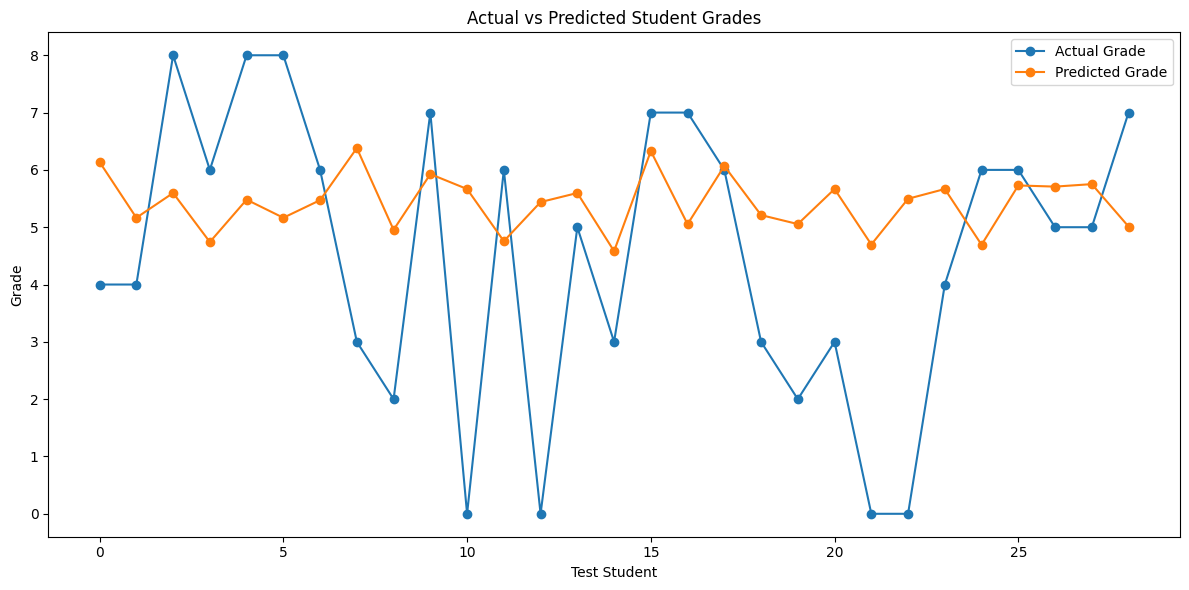

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual Grade"
)

plt.plot(
    y_pred,
    marker="o",
    label="Predicted Grade"
)

plt.title("Actual vs Predicted Student Grades")
plt.xlabel("Test Student")
plt.ylabel("Grade")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Display Linear Regression coefficients

coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficient_df)

,Feature,Coefficient
2,Reading,1.014514
5,Project_work,0.471057
3,Notes,0.042016
0,Weekly_Study_Hours,0.021707
4,Listening_in_Class,-0.111367
1,Attendance,-0.157936


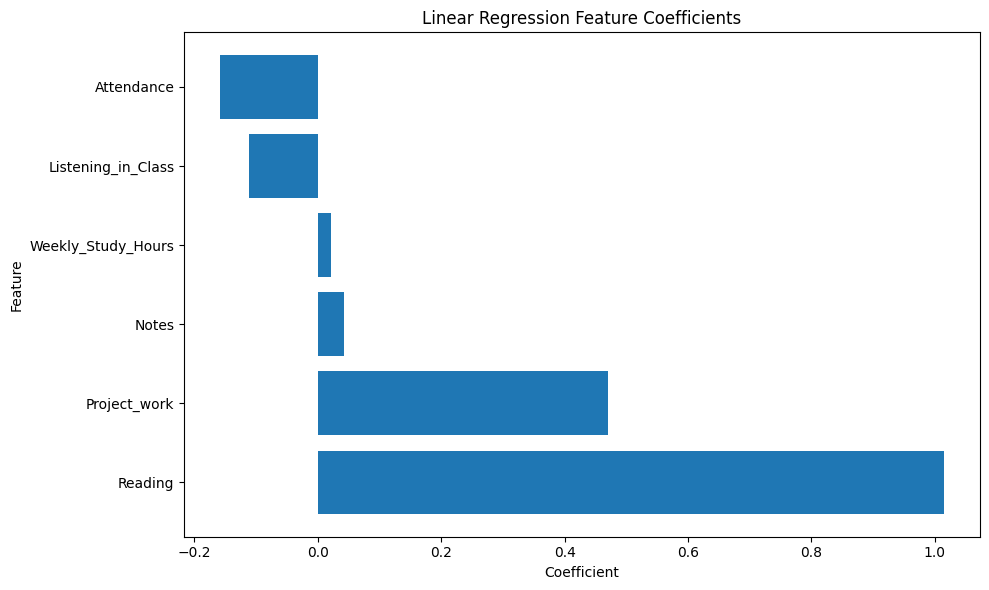

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [29]:
# Final model evaluation summary

print("=" * 50)
print("STUDENT PERFORMANCE PREDICTION - FINAL RESULTS")
print("=" * 50)

print(f"Total Students      : {len(df)}")
print(f"Training Students   : {len(X_train)}")
print(f"Testing Students    : {len(X_test)}")

print("\nModel:")
print("Linear Regression")

print("\nEvaluation Metrics:")
print(f"MAE                 : {mae:.2f}")
print(f"MSE                 : {mse:.2f}")
print(f"R² Score            : {r2:.2f}")

print("\nBest Positive Feature:")
best_feature = coefficient_df.iloc[0]
print(f"{best_feature['Feature']} ({best_feature['Coefficient']:.3f})")

print("\nStrongest Negative Feature:")
worst_feature = coefficient_df.iloc[-1]
print(f"{worst_feature['Feature']} ({worst_feature['Coefficient']:.3f})")

print("=" * 50)

STUDENT PERFORMANCE PREDICTION - FINAL RESULTS
Total Students      : 145
Training Students   : 116
Testing Students    : 29

Model:
Linear Regression

Evaluation Metrics:
MAE                 : 2.15
MSE                 : 6.99
R² Score            : -0.13

Best Positive Feature:
Reading (1.015)

Strongest Negative Feature:
Attendance (-0.158)


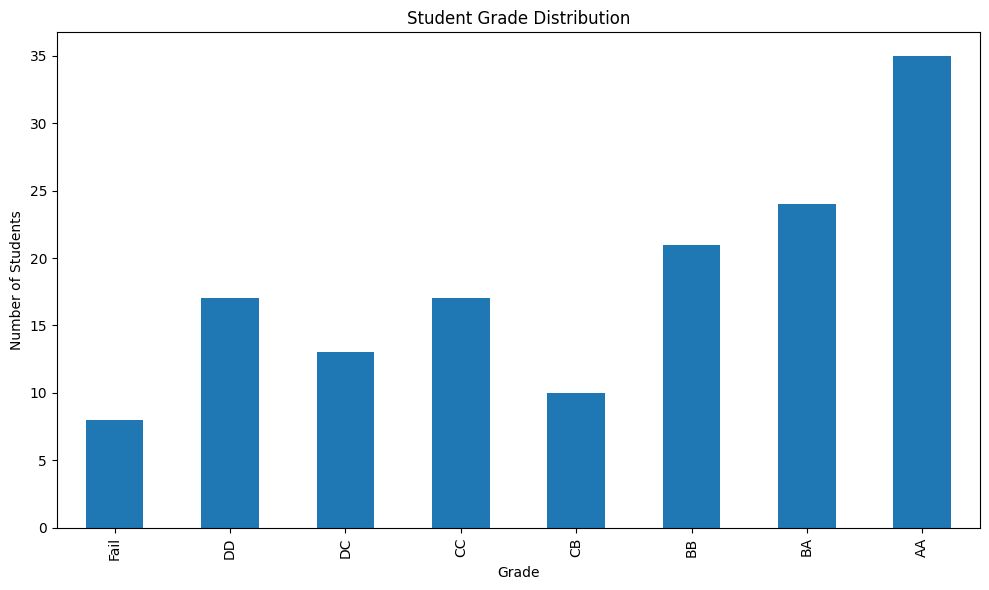

In [30]:
plt.figure(figsize=(10, 6))

df["Grade"].value_counts().reindex(
    ["Fail", "DD", "DC", "CC", "CB", "BB", "BA", "AA"]
).plot(kind="bar")

plt.title("Student Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

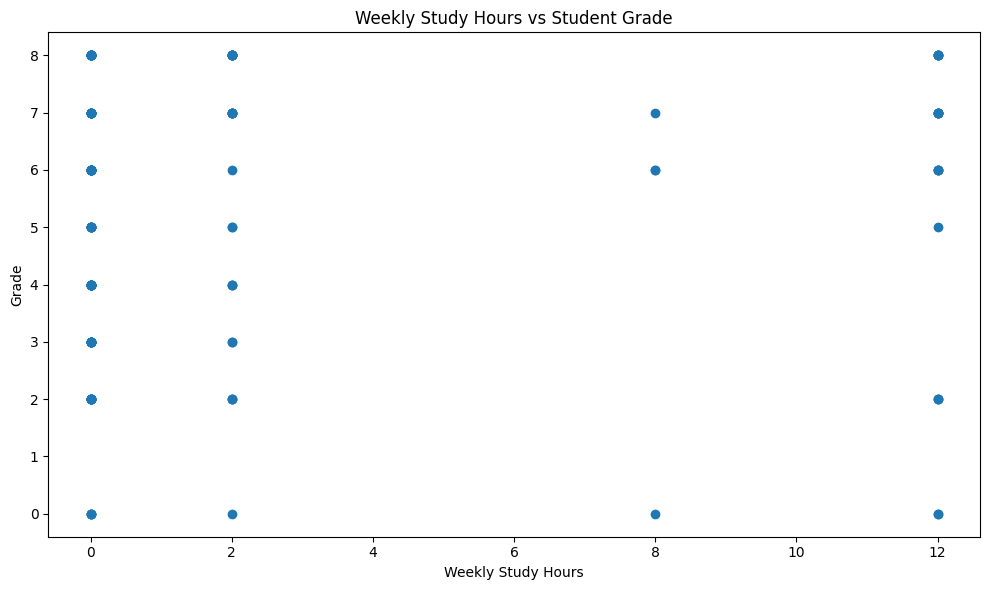

In [31]:
# Study Hours vs Grade

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Weekly_Study_Hours"],
    df["Grade_Numeric"]
)

plt.title("Weekly Study Hours vs Student Grade")
plt.xlabel("Weekly Study Hours")
plt.ylabel("Grade")

plt.tight_layout()
plt.show()

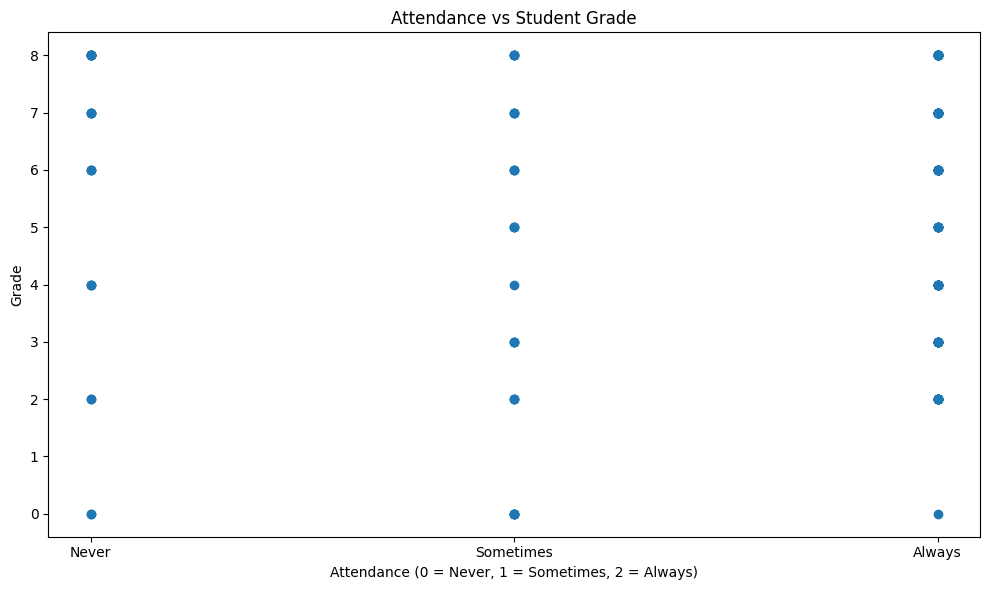

In [32]:
# Attendance vs Grade

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Attendance"],
    df["Grade_Numeric"]
)

plt.title("Attendance vs Student Grade")
plt.xlabel("Attendance (0 = Never, 1 = Sometimes, 2 = Always)")
plt.ylabel("Grade")

plt.xticks(
    [0, 1, 2],
    ["Never", "Sometimes", "Always"]
)

plt.tight_layout()
plt.show()

Average Grade by Attendance:
Attendance
0    5.619048
1    4.200000
2    5.474747
Name: Grade_Numeric, dtype: float64


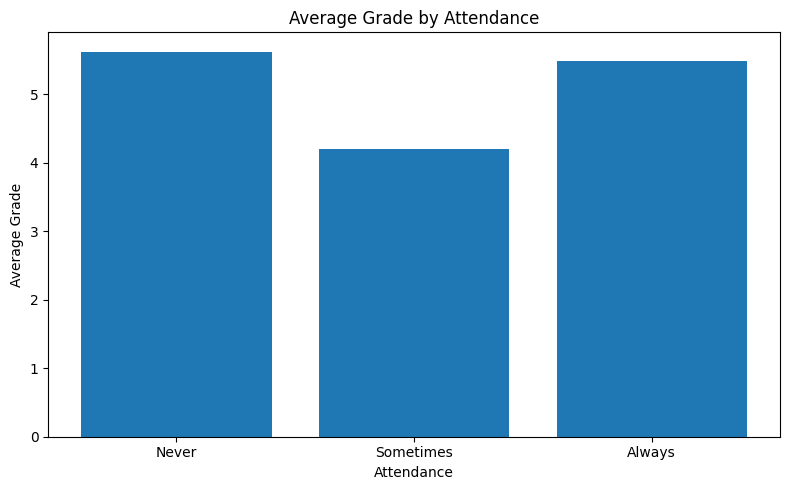

In [33]:
# Average grade by attendance level

attendance_grade = df.groupby("Attendance")["Grade_Numeric"].mean()

print("Average Grade by Attendance:")
print(attendance_grade)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Never", "Sometimes", "Always"],
    attendance_grade.reindex([0, 1, 2])
)

plt.title("Average Grade by Attendance")
plt.xlabel("Attendance")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

Average Grade by Attendance:
Attendance
0    5.619048
1    4.200000
2    5.474747
Name: Grade_Numeric, dtype: float64


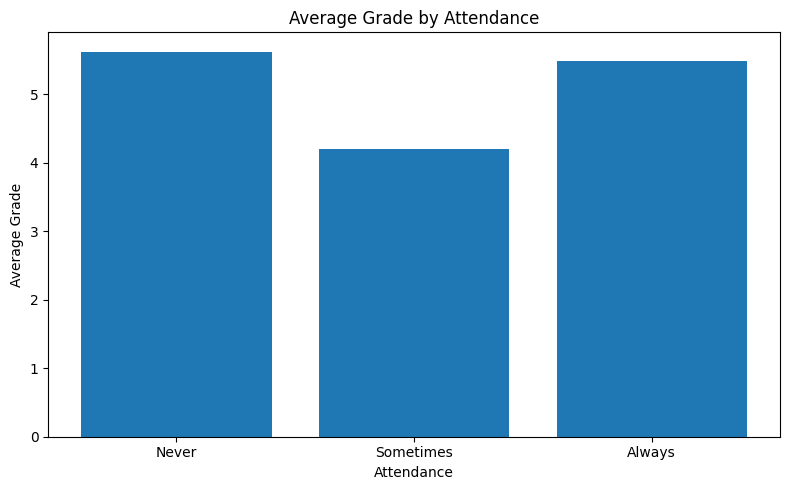

In [34]:
# Average grade by attendance level

attendance_grade = df.groupby("Attendance")["Grade_Numeric"].mean()

print("Average Grade by Attendance:")
print(attendance_grade)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Never", "Sometimes", "Always"],
    attendance_grade.reindex([0, 1, 2])
)

plt.title("Average Grade by Attendance")
plt.xlabel("Attendance")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

Average Grade by Attendance:
Attendance
0    5.619048
1    4.200000
2    5.474747
Name: Grade_Numeric, dtype: float64


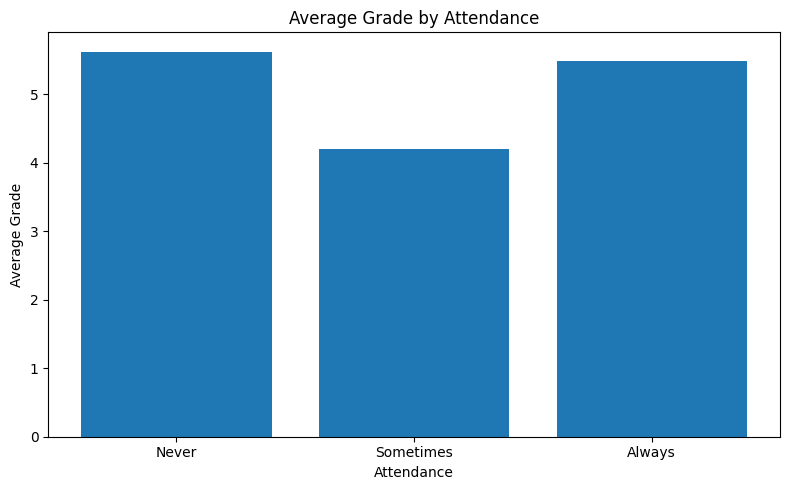

In [35]:
# Average grade by attendance level

attendance_grade = df.groupby("Attendance")["Grade_Numeric"].mean()

print("Average Grade by Attendance:")
print(attendance_grade)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Never", "Sometimes", "Always"],
    attendance_grade.reindex([0, 1, 2])
)

plt.title("Average Grade by Attendance")
plt.xlabel("Attendance")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

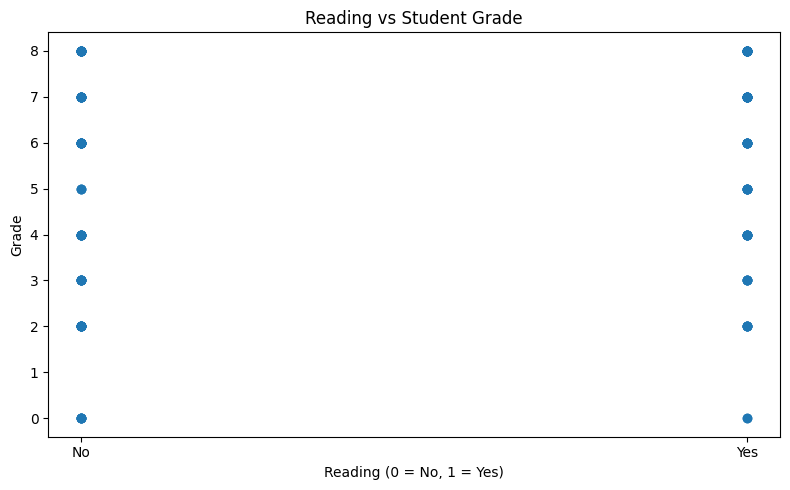

In [36]:
# Reading vs Grade

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Reading"],
    df["Grade_Numeric"]
)

plt.title("Reading vs Student Grade")
plt.xlabel("Reading (0 = No, 1 = Yes)")
plt.ylabel("Grade")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.tight_layout()
plt.show()

Correlation with Grade:
Grade_Numeric         1.000000
Reading               0.160166
Project_work          0.057996
Weekly_Study_Hours    0.054549
Attendance            0.048668
Listening_in_Class    0.046016
Notes                 0.029907
Name: Grade_Numeric, dtype: float64


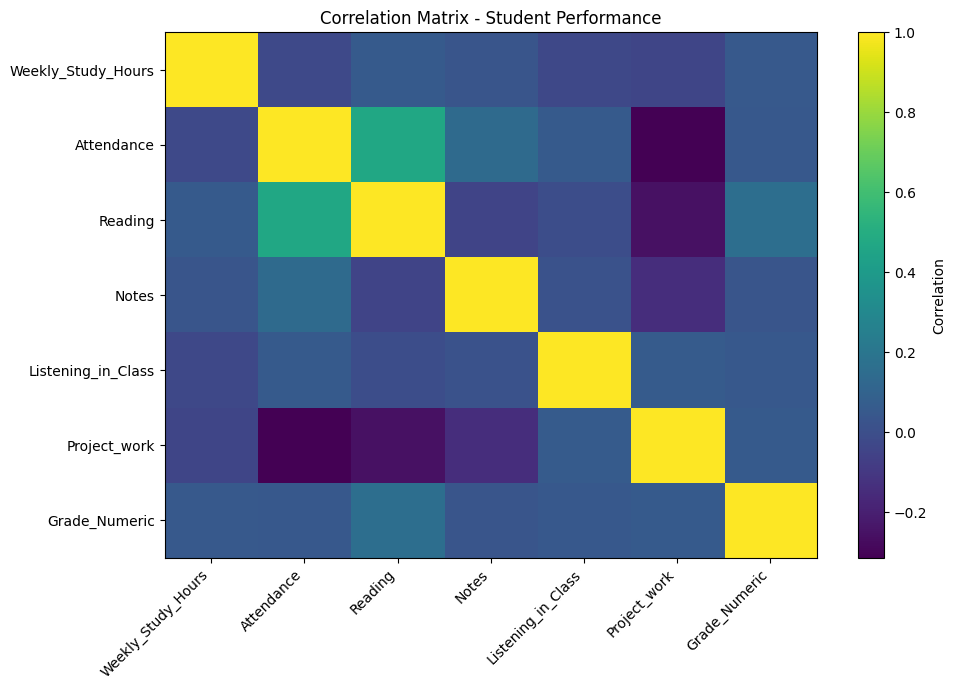

In [37]:
# Correlation analysis

correlation = df[
    [
        "Weekly_Study_Hours",
        "Attendance",
        "Reading",
        "Notes",
        "Listening_in_Class",
        "Project_work",
        "Grade_Numeric"
    ]
].corr()

print("Correlation with Grade:")
print(
    correlation["Grade_Numeric"]
    .sort_values(ascending=False)
)

# Visualize correlation matrix

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix - Student Performance")

plt.tight_layout()
plt.show()

Average Grade by Reading:
Reading
0    4.907895
1    5.681159
Name: Grade_Numeric, dtype: float64


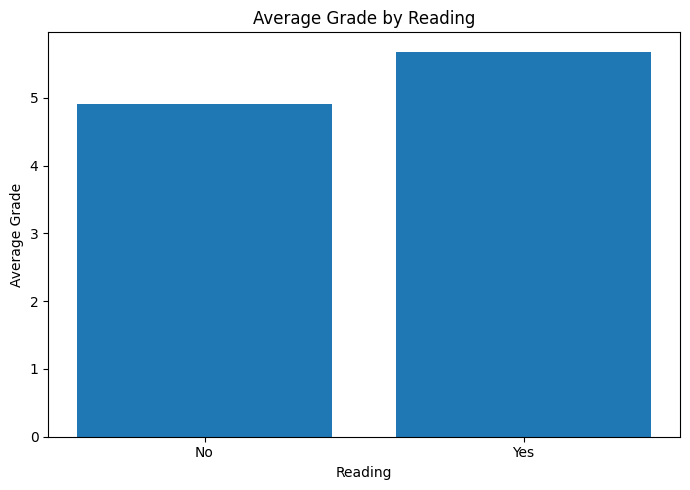

In [38]:
# Average Grade by Reading

reading_grade = df.groupby("Reading")["Grade_Numeric"].mean()

print("Average Grade by Reading:")
print(reading_grade)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No", "Yes"],
    reading_grade.reindex([0, 1])
)

plt.title("Average Grade by Reading")
plt.xlabel("Reading")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

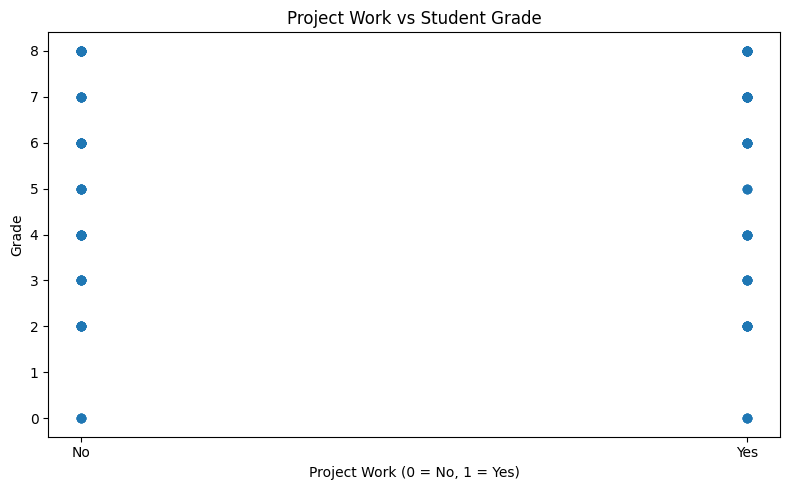

In [39]:
# Project Work vs Grade

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Project_work"],
    df["Grade_Numeric"]
)

plt.title("Project Work vs Student Grade")
plt.xlabel("Project Work (0 = No, 1 = Yes)")
plt.ylabel("Grade")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.tight_layout()
plt.show()

Average Grade by Project Work:
Project_work
0    5.136986
1    5.416667
Name: Grade_Numeric, dtype: float64


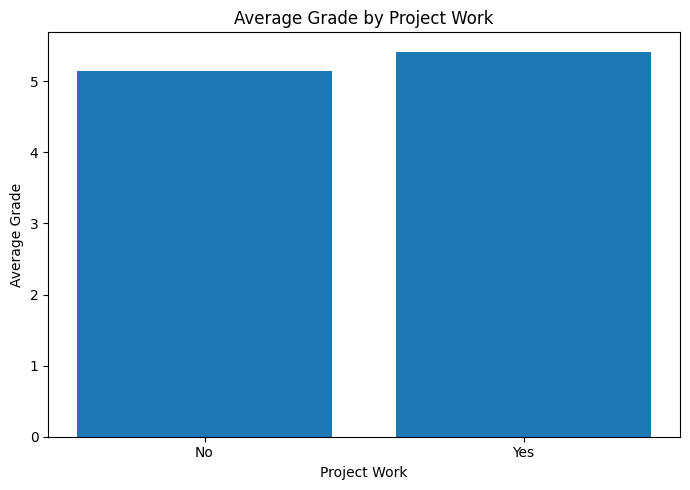

In [40]:
# Average Grade by Project Work

project_grade = df.groupby("Project_work")["Grade_Numeric"].mean()

print("Average Grade by Project Work:")
print(project_grade)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No", "Yes"],
    project_grade.reindex([0, 1])
)

plt.title("Average Grade by Project Work")
plt.xlabel("Project Work")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

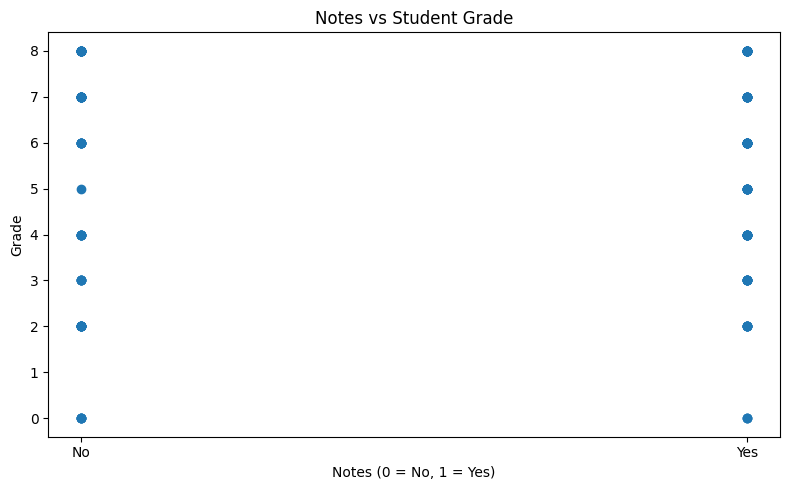

In [41]:
# Notes vs Grade

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Notes"],
    df["Grade_Numeric"]
)

plt.title("Notes vs Student Grade")
plt.xlabel("Notes (0 = No, 1 = Yes)")
plt.ylabel("Grade")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.tight_layout()
plt.show()

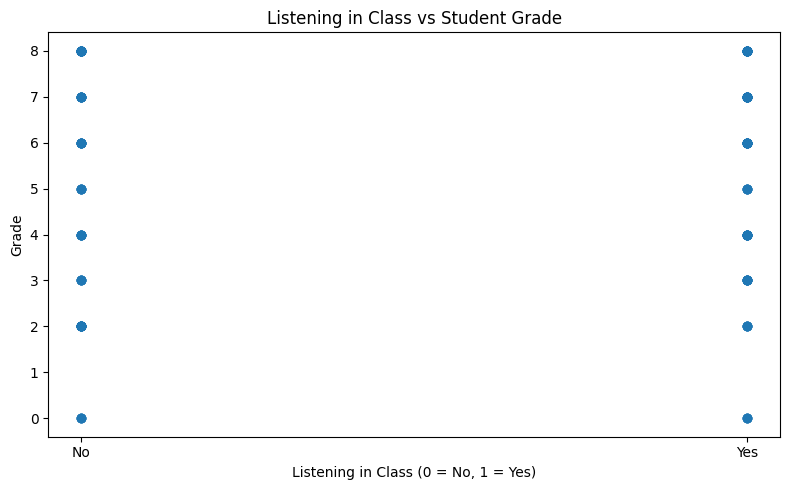

In [42]:
# Listening in Class vs Grade

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Listening_in_Class"],
    df["Grade_Numeric"]
)

plt.title("Listening in Class vs Student Grade")
plt.xlabel("Listening in Class (0 = No, 1 = Yes)")
plt.ylabel("Grade")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.tight_layout()
plt.show()

Average Grade by Listening in Class:
Listening_in_Class
0    5.159420
1    5.381579
Name: Grade_Numeric, dtype: float64


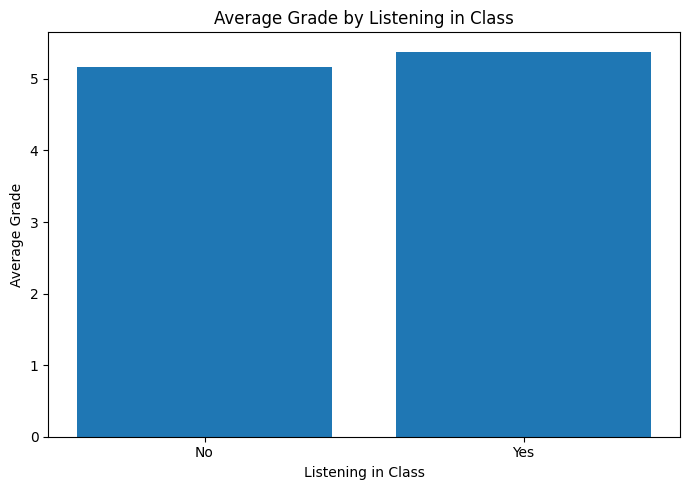

In [43]:
# Average Grade by Listening in Class

listening_grade = df.groupby("Listening_in_Class")["Grade_Numeric"].mean()

print("Average Grade by Listening in Class:")
print(listening_grade)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No", "Yes"],
    listening_grade.reindex([0, 1])
)

plt.title("Average Grade by Listening in Class")
plt.xlabel("Listening in Class")
plt.ylabel("Average Grade")

plt.tight_layout()
plt.show()

In [44]:
# Final EDA summary

print("=" * 50)
print("STUDENT PERFORMANCE - EDA SUMMARY")
print("=" * 50)

print("\nAverage Grade by Reading:")
print(df.groupby("Reading")["Grade_Numeric"].mean())

print("\nAverage Grade by Notes:")
print(df.groupby("Notes")["Grade_Numeric"].mean())

print("\nAverage Grade by Listening in Class:")
print(df.groupby("Listening_in_Class")["Grade_Numeric"].mean())

print("\nAverage Grade by Project Work:")
print(df.groupby("Project_work")["Grade_Numeric"].mean())

print("\nAverage Grade by Attendance:")
print(df.groupby("Attendance")["Grade_Numeric"].mean())

print("\nAverage Grade by Weekly Study Hours:")
print(df.groupby("Weekly_Study_Hours")["Grade_Numeric"].mean())

print("\n" + "=" * 50)
print("EDA completed successfully!")
print("=" * 50)

STUDENT PERFORMANCE - EDA SUMMARY

Average Grade by Reading:
Reading
0    4.907895
1    5.681159
Name: Grade_Numeric, dtype: float64

Average Grade by Notes:
Notes
0    5.196970
1    5.341772
Name: Grade_Numeric, dtype: float64

Average Grade by Listening in Class:
Listening_in_Class
0    5.159420
1    5.381579
Name: Grade_Numeric, dtype: float64

Average Grade by Project Work:
Project_work
0    5.136986
1    5.416667
Name: Grade_Numeric, dtype: float64

Average Grade by Attendance:
Attendance
0    5.619048
1    4.200000
2    5.474747
Name: Grade_Numeric, dtype: float64

Average Grade by Weekly Study Hours:
Weekly_Study_Hours
0     5.107527
2     5.703704
8     4.750000
12    5.571429
Name: Grade_Numeric, dtype: float64

EDA completed successfully!


In [45]:
# Create final prediction results table

final_results = pd.DataFrame({
    "Actual_Grade": y_test.values,
    "Predicted_Grade": y_pred
})

# Round predictions for easier reading
final_results["Predicted_Grade"] = final_results["Predicted_Grade"].round(2)

# Save to CSV
final_results.to_csv(
    "student_performance_predictions.csv",
    index=False
)

print("Final prediction results saved successfully!")

print("\nFirst 10 results:")
display(final_results.head(10))

Final prediction results saved successfully!

First 10 results:


,Actual_Grade,Predicted_Grade
0,4,6.14
1,4,5.16
2,8,5.60
3,6,4.74
4,8,5.48
5,8,5.16
6,6,5.47
7,3,6.38
8,2,4.95
9,7,5.93


In [46]:
# Save model evaluation metrics

evaluation_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "R2 Score"
    ],
    "Value": [
        mae,
        mse,
        r2
    ]
})

evaluation_results.to_csv(
    "model_evaluation_metrics.csv",
    index=False
)

print("Model evaluation metrics saved successfully!")

display(evaluation_results)

Model evaluation metrics saved successfully!


,Metric,Value
0,MAE,2.147874
1,MSE,6.992693
2,R2 Score,-0.131369


In [47]:
# Save the cleaned student performance dataset

df.to_csv(
    "cleaned_student_performance.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully!
Rows: 145
Columns: 16


In [48]:
# Final project summary

print("=" * 60)
print("STUDENT PERFORMANCE PREDICTION PROJECT")
print("=" * 60)

print("\nDataset:")
print(f"Total students: {len(df)}")

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("- Grade_Numeric")

print("\nData Split:")
print(f"- Training data: {len(X_train)} students")
print(f"- Testing data : {len(X_test)} students")

print("\nMachine Learning Model:")
print("- Linear Regression")

print("\nEvaluation Results:")
print(f"- MAE      : {mae:.2f}")
print(f"- MSE      : {mse:.2f}")
print(f"- R² Score : {r2:.2f}")

print("\nImportant Finding:")
print(
    f"- Strongest positive coefficient: "
    f"{coefficient_df.iloc[0]['Feature']} "
    f"({coefficient_df.iloc[0]['Coefficient']:.3f})"
)

print("\nOutput Files:")
print("- cleaned_student_performance.csv")
print("- student_performance_predictions.csv")
print("- model_evaluation_metrics.csv")

print("\nProject completed successfully!")
print("=" * 60)

STUDENT PERFORMANCE PREDICTION PROJECT

Dataset:
Total students: 145

Features used:
- Weekly_Study_Hours
- Attendance
- Reading
- Notes
- Listening_in_Class
- Project_work

Target:
- Grade_Numeric

Data Split:
- Training data: 116 students
- Testing data : 29 students

Machine Learning Model:
- Linear Regression

Evaluation Results:
- MAE      : 2.15
- MSE      : 6.99
- R² Score : -0.13

Important Finding:
- Strongest positive coefficient: Reading (1.015)

Output Files:
- cleaned_student_performance.csv
- student_performance_predictions.csv
- model_evaluation_metrics.csv

Project completed successfully!


In [49]:
# Train Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

# Generate predictions
tree_pred = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")
print("\nFirst 10 predictions:")
print(tree_pred[:10])

Decision Tree model trained successfully!

First 10 predictions:
[7.     4.75   5.9375 2.     5.125  4.75   5.     3.     8.     7.5   ]


In [50]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 2.15


In [51]:
# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))

Mean Squared Error (MSE): 6.99


In [52]:
# Calculate R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 2))

R² Score: -0.13


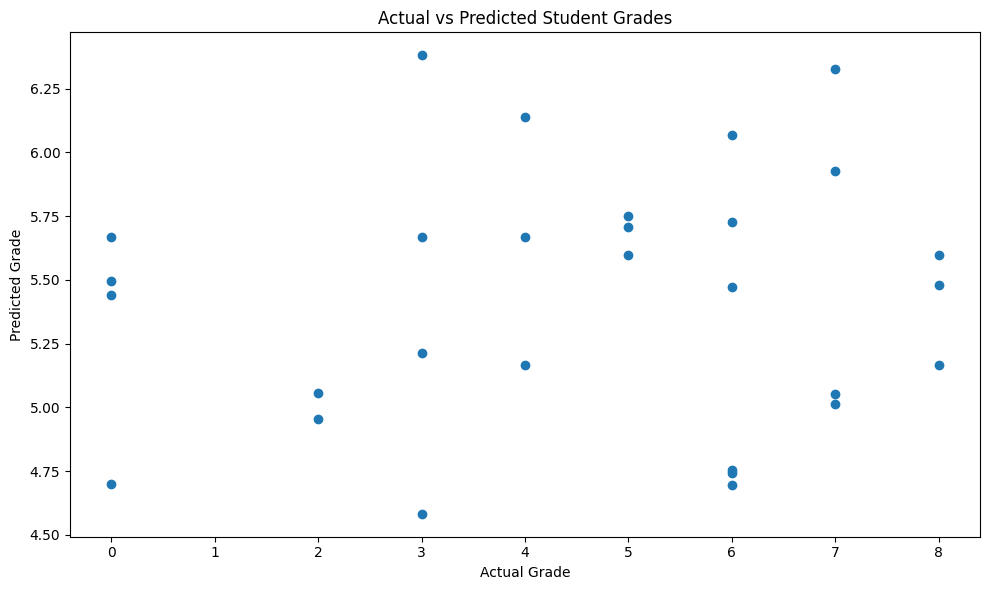

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Student Grades")

plt.tight_layout()
plt.show()

In [54]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [55]:
# Generate Random Forest predictions

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")

print("\nFirst 10 predictions:")
print(rf_pred[:10])

Random Forest predictions generated successfully!

First 10 predictions:
[7.032      5.8217381  6.06992857 4.0924127  6.50966667 5.8217381
 3.89       4.98087302 5.424      7.44166667]


In [56]:
# Calculate Random Forest MAE

rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 2))

Random Forest MAE: 2.02


In [57]:
# Calculate Random Forest MSE

rf_mse = mean_squared_error(y_test, rf_pred)

print("Random Forest MSE:", round(rf_mse, 2))

Random Forest MSE: 5.7


In [58]:
# Calculate Random Forest R² Score

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R² Score:", round(rf_r2, 2))

Random Forest R² Score: 0.08


In [59]:
# Compare Linear Regression and Random Forest

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "MSE": [
        mse,
        rf_mse
    ],
    "R2 Score": [
        r2,
        rf_r2
    ]
})

display(model_comparison.round(2))

,Model,MAE,MSE,R2 Score
0,Linear Regression,2.15,6.99,-0.13
1,Random Forest,2.02,5.70,0.08


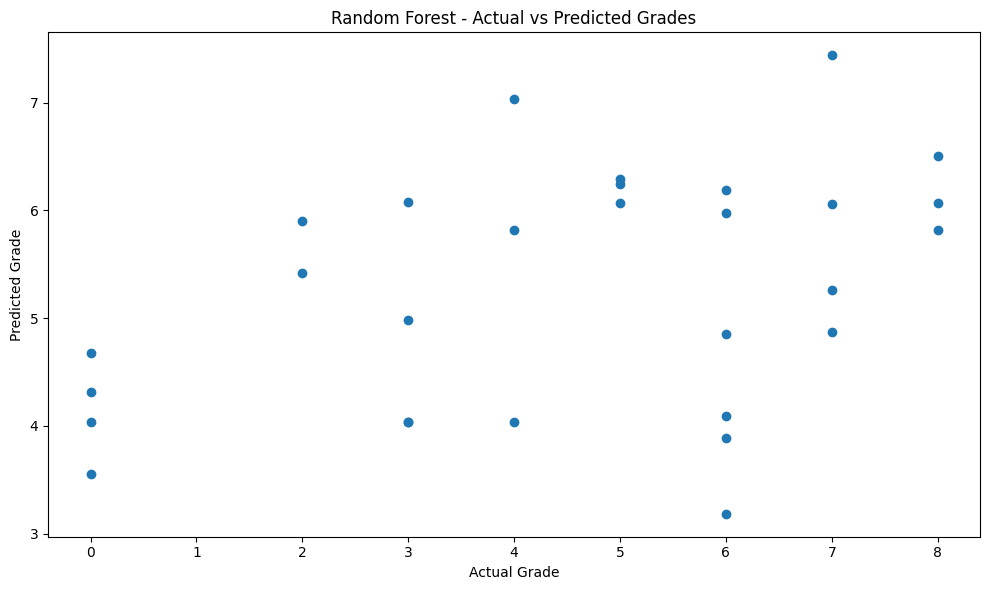

In [60]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Random Forest - Actual vs Predicted Grades")

plt.tight_layout()
plt.show()

In [61]:
# Create final prediction comparison table

final_comparison = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": rf_pred
})

final_comparison["Predicted Grade"] = final_comparison["Predicted Grade"].round(2)

display(final_comparison.head(10))

,Actual Grade,Predicted Grade
0,4,7.03
1,4,5.82
2,8,6.07
3,6,4.09
4,8,6.51
5,8,5.82
6,6,3.89
7,3,4.98
8,2,5.42
9,7,7.44


In [62]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,Weekly_Study_Hours,0.210813
1,Attendance,0.193801
5,Project_work,0.190137
4,Listening_in_Class,0.157931
3,Notes,0.137025
2,Reading,0.110293


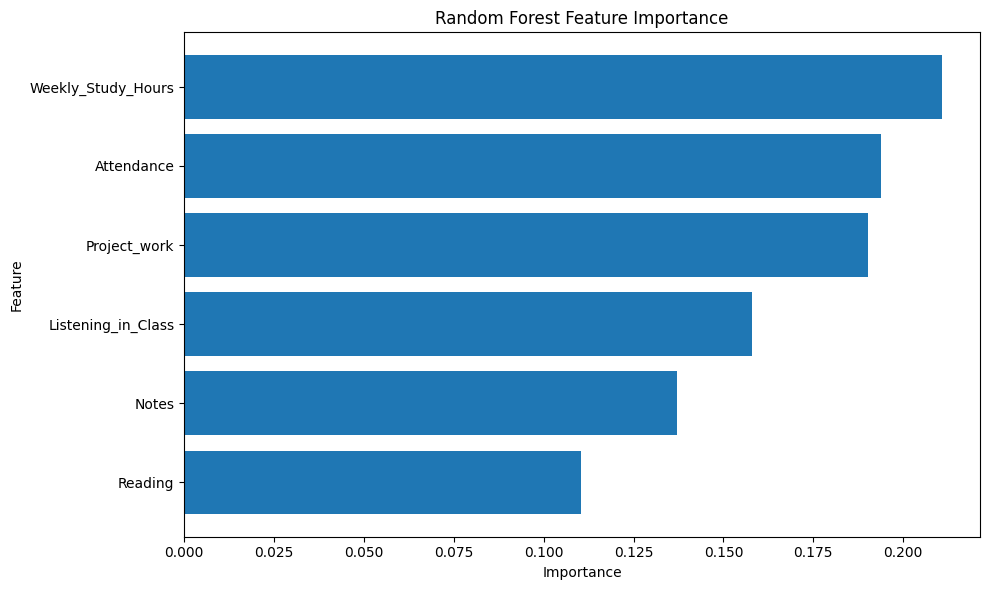

In [63]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [64]:
# Create final prediction results

final_predictions = X_test.copy()

final_predictions["Actual_Grade"] = y_test.values
final_predictions["Predicted_Grade"] = rf_pred

final_predictions["Predicted_Grade"] = (
    final_predictions["Predicted_Grade"].round(2)
)

display(final_predictions.head(10))

,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Actual_Grade,Predicted_Grade
69,0,2,1,0,0,1,4,7.03
140,0,2,0,1,0,1,4,5.82
27,0,2,1,1,1,0,8,6.07
19,2,1,0,0,1,0,6,4.09
42,0,0,0,1,0,1,8,6.51
117,0,2,0,1,0,1,8,5.82
126,12,1,0,1,1,1,6,3.89
108,2,1,1,1,0,1,3,4.98
84,12,2,0,1,0,0,2,5.42
18,12,2,1,0,0,0,7,7.44


In [65]:
# Save final prediction results

final_predictions.to_csv(
    "student_performance_predictions.csv",
    index=False
)

print("Final prediction results saved successfully!")

Final prediction results saved successfully!


In [66]:
# Save model evaluation metrics

model_comparison.to_csv(
    "model_evaluation_metrics.csv",
    index=False
)

print("Model evaluation metrics saved successfully!")

Model evaluation metrics saved successfully!


In [67]:
# Save feature importance results

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [68]:
import os

output_files = [
    "cleaned_student_performance.csv",
    "model_evaluation_metrics.csv",
    "student_performance_predictions.csv",
    "feature_importance.csv"
]

print("Output files:")
print("=" * 40)

for file in output_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

Output files:
✓ cleaned_student_performance.csv
✓ model_evaluation_metrics.csv
✓ student_performance_predictions.csv
✓ feature_importance.csv
